<a href="https://colab.research.google.com/github/dudaoliani/Exerc-cios-Cap-tulo-6/blob/main/Exerc%C3%ADcios_cap%C3%ADtulo_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Módulo de Suporte de Atributos Inicializado com Sucesso.

PROCESSANDO BLOCO 1: EXERCÍCIOS 7.1 A 7.10 (CARTA p)
[RESPOSTA EXERCÍCIO 7.3a] p-barra Inicial: 0.1070
[RESPOSTA EXERCÍCIO 7.3a] Limites Preliminares: LIC = 0.0000 | LSC = 0.2381


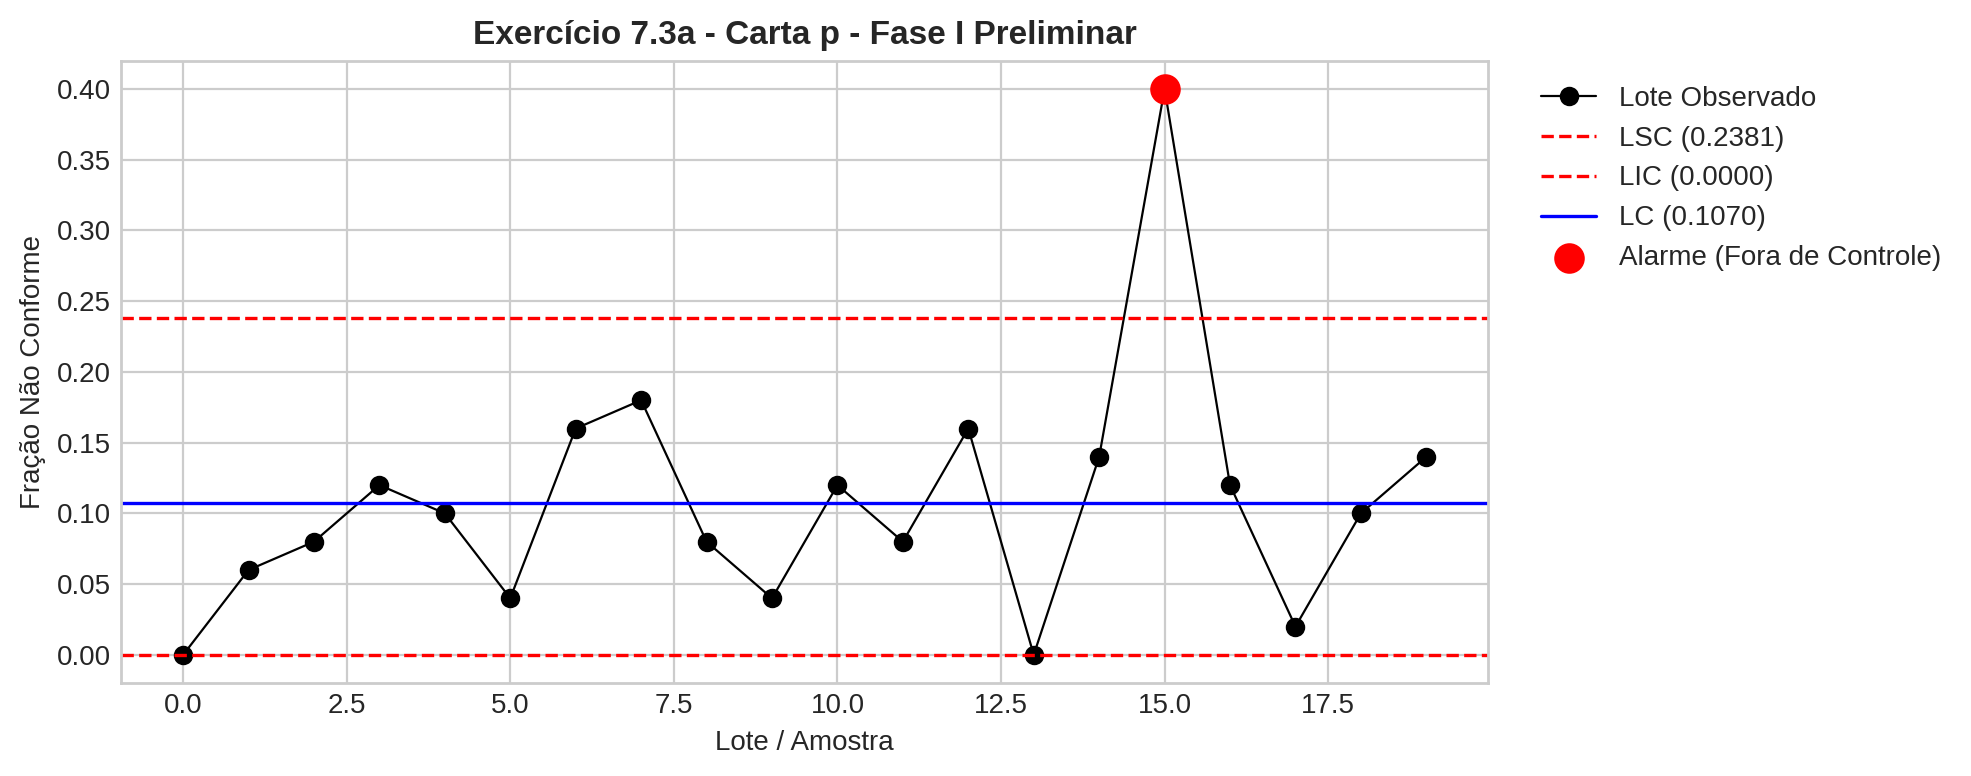

[RESPOSTA EXERCÍCIO 7.3b] Lotes com causas atribuíveis eliminados: [16]
[RESPOSTA EXERCÍCIO 7.3b] Parâmetros Revisados para Fase II: Linha Central = 0.0916 | LSC = 0.2139
[RESPOSTA EXERCÍCIO 7.4] Tamanho amostral mínimo para que LIC > 0: n >= 90

PROCESSANDO BLOCO 2: EXERCÍCIOS 7.11 A 7.30 (AMOSTRA VARIÁVEL & PERFORMANCE)
[RESPOSTA EXERCÍCIO 7.11] Fração Ponderada Central (p-barra): 0.0600 | Tamanho Médio das Amostras (n-médio): 100.0
[RESPOSTA EXERCÍCIO 7.11] Matriz de Limites Variáveis Calculada por Lote:
 Dia  n_inspecionado  p_amostral  LIC_Variavel  LSC_Variavel
   1              80    0.050000           0.0      0.139656
   2             110    0.063636           0.0      0.127930
   3              90    0.055556           0.0      0.135100
   4              75    0.106667           0.0      0.142268
   5             130    0.046154           0.0      0.122487
   6             120    0.050000           0.0      0.125038
   7              70    0.057143           0.0      0.145155

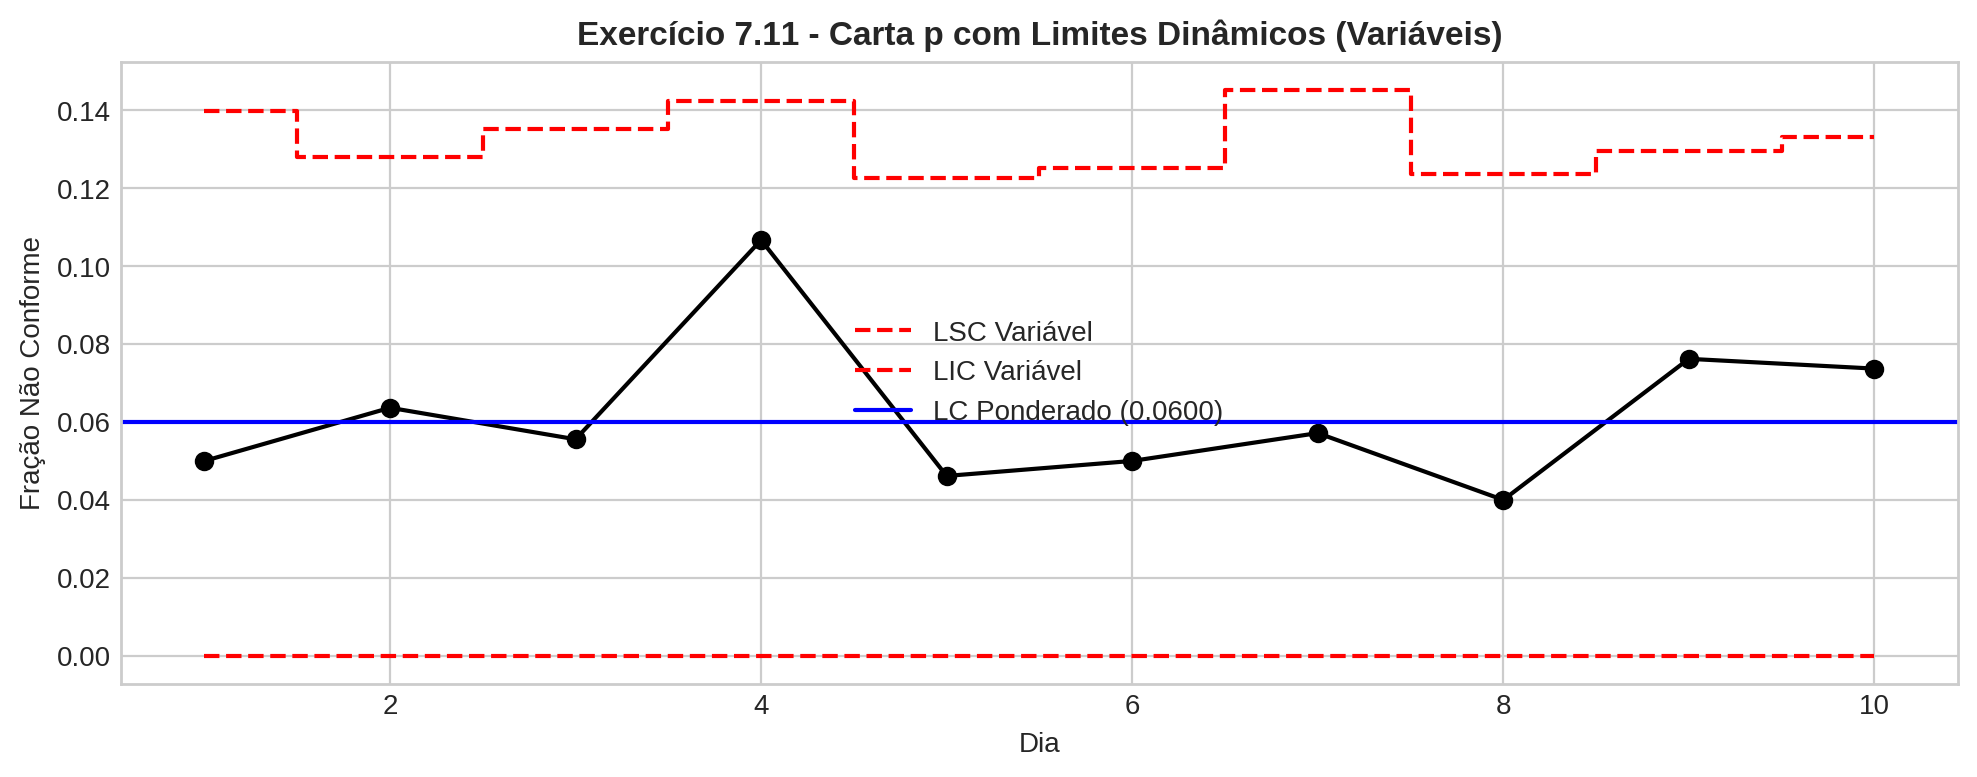

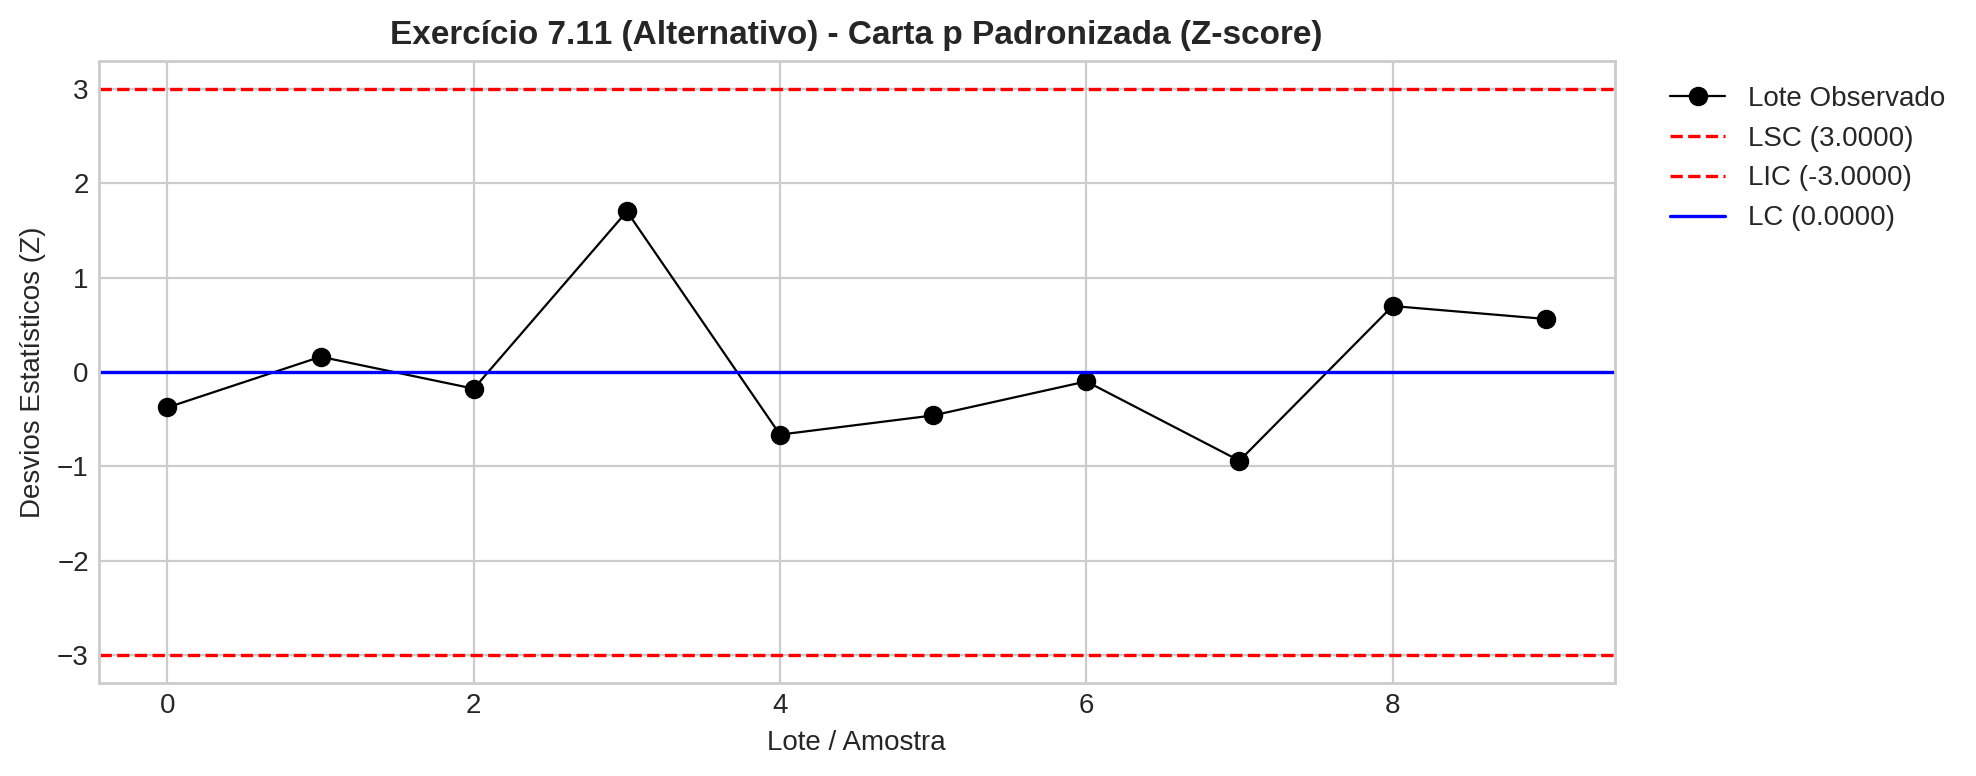

[RESPOSTA EXERCÍCIO 7.15] Limite de Aceitação Inteiro (c): 3 peças
[RESPOSTA EXERCÍCIO 7.15] Risco Beta (Falso Negativo para p=0.04): 0.8609
[RESPOSTA EXERCÍCIO 7.15] Poder de Detecção (1 - Beta): 13.91%
[RESPOSTA EXERCÍCIO 7.15] ARL_1 (Amostras até o primeiro alarme real): 7.19


In [2]:
# ==============================================================================
# SCRIPT UNIFICADO: CONTROLE ESTATÍSTICO DE PROCESSO (CAPÍTULO 7 - ATRIBUTOS)
# ==============================================================================
# Resolução Automatizada dos Exercícios do Capítulo 7 (Montgomery 7ª Edição)
# Cobertura: Cartas p, np, c, u, Análise de Performance (CO/ARL) e Padrão 105E.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ------------------------------------------------------------------------------
# MÓDULO 0: CONFIGURAÇÕES VISUAIS E FUNÇÃO DE PLOTAGEM PADRONIZADA
# ------------------------------------------------------------------------------
%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def plotar_carta_atributo(dados, lsc, lic, lc, id_exercicio, descricao_carta, ylabel="Proporção / Contagem"):
    """Gera gráficos de controle de atributos destacando alarmes estatísticos."""
    plt.figure(figsize=(10, 4))
    plt.plot(dados, marker='o', color='black', linestyle='-', linewidth=0.8, label='Lote Observado')
    plt.axhline(lsc, color='red', linestyle='--', linewidth=1.2, label=f'LSC ({lsc:.4f})')
    plt.axhline(lic, color='red', linestyle='--', linewidth=1.2, label=f'LIC ({lic:.4f})')
    plt.axhline(lc, color='blue', linestyle='-', linewidth=1.2, label=f'LC ({lc:.4f})')

    # Detecção e Realce de pontos Fora de Controle (OOC)
    alarmes = dados[(dados > lsc) | (dados < lic)]
    if not alarmes.empty:
        plt.scatter(alarmes.index, alarmes, color='red', s=100, zorder=5, label='Alarme (Fora de Controle)')

    plt.title(f"Exercício {id_exercicio} - {descricao_carta}", fontsize=12, fontweight='bold')
    plt.xlabel("Lote / Amostra")
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("Módulo de Suporte de Atributos Inicializado com Sucesso.")

# ------------------------------------------------------------------------------
# BLOCO 1: EXERCÍCIOS 7.1 A 7.10 (CARTA p - FRAÇÃO NÃO CONFORME)
# ------------------------------------------------------------------------------
print("\n" + "="*70 + "\nPROCESSANDO BLOCO 1: EXERCÍCIOS 7.1 A 7.10 (CARTA p)\n" + "="*70)

# Dados do problema de Reivindicações de Seguro Médico (Tabela 7E.1)
dados_73 = {
    'Lote': range(1, 21),
    'N_NaoConforme': [0, 3, 4, 6, 5, 2, 8, 9, 4, 2, 6, 4, 8, 0, 7, 20, 6, 1, 5, 7]
}
df_73 = pd.DataFrame(dados_73)
n_73 = 50 # Tamanho constante de amostra preliminar

df_73['p_amostral'] = df_73['N_NaoConforme'] / n_73

# Cálculo preliminar da Fase I (Exercício 7.3a)
p_barra_inicial = df_73['N_NaoConforme'].sum() / (len(df_73) * n_73)
lsc_p_init = p_barra_inicial + 3 * np.sqrt((p_barra_inicial * (1 - p_barra_inicial)) / n_73)
lic_p_init = max(0, p_barra_inicial - 3 * np.sqrt((p_barra_inicial * (1 - p_barra_inicial)) / n_73))

print(f"[RESPOSTA EXERCÍCIO 7.3a] p-barra Inicial: {p_barra_inicial:.4f}")
print(f"[RESPOSTA EXERCÍCIO 7.3a] Limites Preliminares: LIC = {lic_p_init:.4f} | LSC = {lsc_p_init:.4f}")
plotar_carta_atributo(df_73['p_amostral'], lsc_p_init, lic_p_init, p_barra_inicial, "7.3a", "Carta p - Fase I Preliminar", "Fração Não Conforme")

# Purga de Dados e Revisão (Exercício 7.3b)
lotes_ooc = df_73[df_73['p_amostral'] > lsc_p_init].index.tolist()
df_73_limpo = df_73.drop(lotes_ooc)

p_barra_rev = df_73_limpo['N_NaoConforme'].sum() / (len(df_73_limpo) * n_73)
lsc_p_rev = p_barra_rev + 3 * np.sqrt((p_barra_rev * (1 - p_barra_rev)) / n_73)
lic_p_rev = max(0, p_barra_rev - 3 * np.sqrt((p_barra_rev * (1 - p_barra_rev)) / n_73))

print(f"[RESPOSTA EXERCÍCIO 7.3b] Lotes com causas atribuíveis eliminados: {[x+1 for x in lotes_ooc]}")
print(f"[RESPOSTA EXERCÍCIO 7.3b] Parâmetros Revisados para Fase II: Linha Central = {p_barra_rev:.4f} | LSC = {lsc_p_rev:.4f}")

# Dimensionamento Amostral para Limite Inferior Positivo (Exercício 7.4)
n_necessario_lic = ((3**2) * (1 - p_barra_rev)) / p_barra_rev
print(f"[RESPOSTA EXERCÍCIO 7.4] Tamanho amostral mínimo para que LIC > 0: n >= {int(np.ceil(n_necessario_lic))}")

# ------------------------------------------------------------------------------
# BLOCO 2: EXERCÍCIOS 7.11 A 7.20 (CARTA p COM TAMANHO DE AMOSTRA VARIÁVEL)
# ------------------------------------------------------------------------------
print("\n" + "="*70 + "\nPROCESSANDO BLOCO 2: EXERCÍCIOS 7.11 A 7.30 (AMOSTRA VARIÁVEL & PERFORMANCE)\n" + "="*70)

# Dados do problema de Inspeção de Computadores Pessoais (Tabela 7E.5)
dados_711 = {
    'Dia': range(1, 11),
    'n_inspecionado': [80, 110, 90, 75, 130, 120, 70, 125, 105, 95],
    'D_defeitos': [4, 7, 5, 8, 6, 6, 4, 5, 8, 7]
}
df_711 = pd.DataFrame(dados_711)
df_711['p_amostral'] = df_711['D_defeitos'] / df_711['n_inspecionado']

p_ponderado_global = df_711['D_defeitos'].sum() / df_711['n_inspecionado'].sum()
n_medio = df_711['n_inspecionado'].mean()

# Métodos de Tratamento (Exercício 7.11)
df_711['LSC_Variavel'] = p_ponderado_global + 3 * np.sqrt((p_ponderado_global * (1 - p_ponderado_global)) / df_711['n_inspecionado'])
df_711['LIC_Variavel'] = (p_ponderado_global - 3 * np.sqrt((p_ponderado_global * (1 - p_ponderado_global)) / df_711['n_inspecionado'])).clip(lower=0)

# Método de Carta p Padronizada (Z)
df_711['Z_score'] = (df_711['p_amostral'] - p_ponderado_global) / np.sqrt((p_ponderado_global * (1 - p_ponderado_global)) / df_711['n_inspecionado'])

print(f"[RESPOSTA EXERCÍCIO 7.11] Fração Ponderada Central (p-barra): {p_ponderado_global:.4f} | Tamanho Médio das Amostras (n-médio): {n_medio:.1f}")
print("[RESPOSTA EXERCÍCIO 7.11] Matriz de Limites Variáveis Calculada por Lote:")
print(df_711[['Dia', 'n_inspecionado', 'p_amostral', 'LIC_Variavel', 'LSC_Variavel']].to_string(index=False))

# Plotagem da Carta com Limites Dinâmicos em Escada
plt.figure(figsize=(10, 4))
plt.plot(df_711['Dia'], df_711['p_amostral'], marker='o', color='black', linestyle='-')
plt.step(df_711['Dia'], df_711['LSC_Variavel'], color='red', linestyle='--', where='mid', label='LSC Variável')
plt.step(df_711['Dia'], df_711['LIC_Variavel'], color='red', linestyle='--', where='mid', label='LIC Variável')
plt.axhline(p_ponderado_global, color='blue', label=f'LC Ponderado ({p_ponderado_global:.4f})')
plt.title("Exercício 7.11 - Carta p com Limites Dinâmicos (Variáveis)", fontweight='bold')
plt.xlabel("Dia")
plt.ylabel("Fração Não Conforme")
plt.legend()
plt.tight_layout()
plt.show()

# Plotagem da Carta Padronizada Z-score
plotar_carta_atributo(df_711['Z_score'], 3.0, -3.0, 0.0, "7.11 (Alternativo)", "Carta p Padronizada (Z-score)", "Desvios Estatísticos (Z)")

# --- ANÁLISE DE PERFORMANCE OPERACIONAL (Exercício 7.15) ---
p_fase2_alvo = 0.02
n_fase2 = 50
p_fase2_deslocado = 0.04

# Probabilidade de detecção na primeira amostra (1 - Beta) via Binomial Pura
lsc_np_teorico = n_fase2 * p_fase2_alvo + 3 * np.sqrt(n_fase2 * p_fase2_alvo * (1 - p_fase2_alvo))
c_aceitacao_teorico = int(np.floor(lsc_np_teorico))

beta_fase2 = stats.binom.cdf(c_aceitacao_teorico, n_fase2, p_fase2_deslocado)
poder_fase2 = 1 - beta_fase2
arl_1_fase2 = 1 / poder_fase2

print(f"[RESPOSTA EXERCÍCIO 7.15] Limite de Aceitação Inteiro (c): {c_aceitacao_teorico} peças")
print(f"[RESPOSTA EXERCÍCIO 7.15] Risco Beta (Falso Negativo para p={p_fase2_deslocado}): {beta_fase2:.4f}")
print(f"[RESPOSTA EXERCÍCIO 7.15] Poder de Detecção (1 - Beta): {poder_fase2*100:.2f}%")
print(f"[RESPOSTA EXERCÍCIO 7.15] ARL_1 (Amostras até o primeiro alarme real): {arl_1_fase2:.2f}")